In [35]:
from extract import extract_graph , extract_die_area , load_file_content

# Define your file paths
#extra def text
file_name = "picorv32_run_20260306_121428"
design_name = file_name.split("_")[0]
print(design_name)
def_path = f"dataset_with_def/placement_files/{file_name}/{design_name}.def"
saif_path = f"dataset_with_def/placement_files/{file_name}/{design_name}.saif"
timing_path = f"dataset_with_def/placement_files/{file_name}/timing_paths.csv"
def_text = load_file_content(design_path) 
saif_text = load_file_content(saif_path)

# One function call to get everything!
graph = extract_graph(def_path, saif_path, timing_path, clock_port="clk")
def_text = load_file_content(def_path)
die_x_min, die_y_min, die_x_max, die_y_max = extract_die_area(def_text)



print("\nExtraction Complete!")
print(f"Nodes: {len(graph['nodes'])}")
print(f"Skip edges: {graph['skip_edges'].shape}")
print(f"Directed edges: {graph['directed_edges'].shape}")
print(f"Undirected edges: {graph['undirected_edges'].shape}")
print(f"Die area: x[{die_x_min}, {die_x_max}], y[{die_y_min}, {die_y_max}]")    

for a, b in graph['skip_edges'][:5]:  # Print first 5 skip edges
    print(f"Skip edge: {a, b}")

picorv32
Flip-flops: 1597
Unique pairs: 3159, dropped: 0
Skip edges shape: (3159, 2)
Nodes: 7292
Directed edges: 20441
Undirected edges: 40882
Flip-flops: 1597
Fan-in  — max: 6, avg: 2.8
Fan-out — max: 236, avg: 2.8

Extraction Complete!
Nodes: 7292
Skip edges: (3159, 2)
Directed edges: (20441, 2)
Undirected edges: (40882, 2)
Die area: x[0, 587425], y[0, 425230]
Skip edge: (np.int64(6113), np.int64(5946))
Skip edge: (np.int64(6113), np.int64(5944))
Skip edge: (np.int64(5304), np.int64(6083))
Skip edge: (np.int64(6113), np.int64(5942))
Skip edge: (np.int64(6113), np.int64(5945))


In [36]:
import numpy as np 
import torch

def normalize_features(nodes, die_x_min, die_y_min, die_x_max, die_y_max):
    die_w = die_x_max - die_x_min
    die_h = die_y_max - die_y_min
    
    cell_ids = []
    numeric = []
    
    for n in nodes:
        row = [
            (n['x'] - die_x_min) / die_w,
            (n['y'] - die_y_min) / die_h,
            n['dist_to_boundaries'][0] / die_w,
            n['dist_to_boundaries'][1] / die_w,
            n['dist_to_boundaries'][2] / die_h,
            n['dist_to_boundaries'][3] / die_h,
            np.log1p(n['cell_area']),
            n['avg_pin_cap'] * 1000,
            n['total_pin_cap'] * 1000,
            np.log2(max(n['drive_strength'], 1)),
            float(n['is_sequential']),
            float(n['is_buffer']),
            n['toggle_count'],
            n['sum_toggle_count'],
            n['signal_prob'],
            float(n['non_zero_count']),
            np.log1p(n['fan_in']),
            np.log1p(n['fan_out']),
        ]
        numeric.append(row)
        cell_ids.append(n['cell_type_id'])
    
    features = torch.tensor(numeric, dtype=torch.float32)
    cell_type_ids = torch.tensor(cell_ids, dtype=torch.long)
    
    # Standardize all columns except binary flags (indices 10, 11)
    binary_cols = {10, 11}
    norm_stats = {}
    
    for col in range(features.shape[1]):
        if col in binary_cols:
            continue
        mean = features[:, col].mean()
        std = features[:, col].std()
        if std > 1e-8:
            features[:, col] = (features[:, col] - mean) / std
            norm_stats[col] = (mean.item(), std.item())
    
    return features, cell_type_ids, norm_stats

# Assuming 'graph' and 'die_x_min' etc. are already defined from previous cells
X_float, X_cell_ids, norm_stats = normalize_features(
    graph['nodes'], 
    die_x_min, die_y_min, die_x_max, die_y_max
)

print("-" * 30)
print("NORMALIZATION RESULTS")
print("-" * 30)
print(f"X_float shape:    {X_float.shape} (Standardized continuous features)")
print(f"X_cell_ids shape: {X_cell_ids.shape} (Categorical IDs for embeddings)")
print(f"Number of normalized columns: {len(norm_stats)}")

# Sample check on first node
print("\nFirst Node Normalized Features:")
print(X_float[17])
print(X_cell_ids[17])


# Verify the categorical ID
print(f"\nFirst Node Cell Type ID: {X_cell_ids[0].item()}")
print(f"\nSecond Node Cell Type ID: {X_cell_ids[1045].item()}")

------------------------------
NORMALIZATION RESULTS
------------------------------
X_float shape:    torch.Size([7292, 18]) (Standardized continuous features)
X_cell_ids shape: torch.Size([7292]) (Categorical IDs for embeddings)
Number of normalized columns: 16

First Node Normalized Features:
tensor([ 1.1976, -1.1295,  1.1976, -1.1976,  1.1295, -1.1295,  0.0328,  9.5839,
         2.2447,  4.4932,  0.0000,  1.0000, -0.9128, -0.9131,  1.6478, -0.7822,
        -1.2385,  3.7120])
tensor(204)

First Node Cell Type ID: 201

Second Node Cell Type ID: 275


In [37]:
import scipy.sparse as sp
import numpy as np

def build_X_hop_mask(n_nodes, undirected_edges, hop_mask_len=3):
    """
    Creates the Omega mask. 
    If Omega[i, j] = 1, Node i is allowed to 'use' Node j for reconstruction.
    """
    # 1. Slice out the Source (rows) and Destination (cols) nodes
    u_rows = undirected_edges[:, 0]
    u_cols = undirected_edges[:, 1]
    
    # 2. Build the initial 1-hop Sparse Adjacency Matrix (A)
    # Using bool to save memory (we only care IF a wire exists)
    A = sp.csr_matrix((np.ones(len(u_rows), dtype=bool), (u_rows, u_cols)), 
                      shape=(n_nodes, n_nodes))
    
    # 3. Matrix Power Expansion (Find 2-hop and 3-hop neighbors)
    omega = A.copy()
    temp = A.copy()
    
    for i in range(2, hop_mask_len + 1):
        temp = temp.dot(A)
        omega = omega + temp
        print(f"  -> Hop {i} expansion complete.")

    # 4) diag(P) = 0
    # A node cannot reconstruct itself
    omega.setdiag(0)
    omega.eliminate_zeros()
    
    # 5. Convert back to coordinates for PyTorch
    omega_coo = omega.tocoo()
    
    print(f"Mask created! {omega_coo.nnz:,} total connections allowed.")
    return omega_coo.row, omega_coo.col


# Pass the length and the edges explicitly 
p_rows, p_cols = build_X_hop_mask(
    n_nodes=len(graph['nodes']), 
    undirected_edges=graph['undirected_edges'], 
    hop_mask_len=3
)


# # 1. Create a reverse dictionary to turn indices back into DEF instance names
# idx_to_node = {idx: name for name, idx in graph['node_to_idx'].items()}

# # 2. Check the overall density (How heavy is this for the GPU?)
# total_edges = len(p_rows)
# total_nodes = len(graph['nodes'])
# avg_neighbors = total_edges / total_nodes

# print("--- MASK STATISTICS ---")
# print(f"Total Nodes (Gates): {total_nodes:,}")
# print(f"Total Allowed Connections in Mask: {total_edges:,}")
# print(f"Average 3-Hop Neighbors per Gate: {avg_neighbors:.1f}")

# # 3. Peek at the actual relationships (The first 10 connections)
# print("\n--- SAMPLE CONNECTIONS (Who can see who?) ---")
# for i in range(10):
#     target_idx = p_rows[i]
#     neighbor_idx = p_cols[i]
    
#     target_name = idx_to_node[target_idx]
#     neighbor_name = idx_to_node[neighbor_idx]
    
#     print(f"Target Gate [{target_idx:5}]: {target_name:<20} <-- looks at --> Neighbor [{neighbor_idx:5}]: {neighbor_name}")

# # 4. Look at a specific gate's neighborhood
# sample_gate_idx = p_rows[0] # Let's pick whatever gate happens to be first
# sample_gate_name = idx_to_node[sample_gate_idx]

# # Find all neighbors for this specific gate
# neighbors_of_sample = p_cols[p_rows == sample_gate_idx]

# print(f"\n--- SPOTLIGHT: Gate '{sample_gate_name}' ---")
# print(f"This gate has {len(neighbors_of_sample)} neighbors within 3 hops.")
# print(f"First 5 neighbors it will use for reconstruction:")
# for n_idx in neighbors_of_sample[:5]:
#     print(f"  - {idx_to_node[n_idx]}")



  -> Hop 2 expansion complete.
  -> Hop 3 expansion complete.
Mask created! 2,155,726 total connections allowed.


In [61]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

class FirstTerm(nn.Module):
    def __init__(self, indices, num_nodes , num_cell_types, num_of_clusters, A_skip_csr , embedding_dim=8):
        super().__init__()
        self.register_buffer('indices', indices)
        self.cell_embedding = nn.Embedding(num_cell_types, embedding_dim)
        # Initialize 10.9M weights (The Dials)
        self.p_weights = nn.Parameter(torch.randn(indices.shape[1]) * 0.01)
        self.num_nodes = num_nodes
        self.A_skip_csr = A_skip_csr

        # 3. THE CLUSTER HEAD (The C-Matrix Generator)
        # This replaces the N x K parameter bottleneck.
        self.cluster_head = nn.Sequential(
            nn.Linear(18 + embedding_dim, 64), 
            nn.ReLU(),
            nn.Linear(64, num_of_clusters)      # Output is K clusters
        )

    def forward(self, X, X_cell_ids, tau=1.0):
        cell_features = self.cell_embedding(X_cell_ids)  # Shape: [num_nodes, embedding_dim]
        X_combined = torch.cat([X, cell_features], dim=1)  # Shape: [num_nodes, 18 + embedding_dim]


        # Enforce P >= 0 and build sparse matrix
        P = torch.sparse_coo_tensor(self.indices, torch.relu(self.p_weights)  + 1e-6, 
                                    (self.num_nodes, self.num_nodes)).coalesce()
        
        # Reconstruction: XP
        X_hat = torch.sparse.mm(P, X)
        
        # Loss: ||X - XP||
        error = X - X_hat
        loss1 = torch.sum(error ** 2)   

        # Pass all node features through the head
        logits = self.cluster_head(X_combined) # Shape: [n, k]
        
        #TERM2
        #C matrix with probability distribution across clusters for each node
        C = F.gumbel_softmax(logits, tau=tau, hard=False) # Shape: [n, k]
        # C = F.softmax(logits, dim=-1)  # Ensure positivity for SDDMM

        p_vals = P.values()
        
        # 1. Sum across rows (dim=1) to get the total weight leaving each node
        row_sums = torch.sparse.sum(P, dim=1).to_dense()
        
        # 2. Expand row_sums to match the non-zero values 
        # P.indices()[0] contains the row index for every specific edge
        p_vals_norm = p_vals / (row_sums[P.indices()[0]] + 1e-8)
        
        # Rebuild using the exact same sorted indices
        P_norm = torch.sparse_coo_tensor(P.indices(), p_vals_norm, 
                                         (self.num_nodes, self.num_nodes)).coalesce()
        
        # 2. Convert to CSR format (Required for the CUDA SDDMM engine)
        P_csr = P_norm.to_sparse_csr()
        
        # 3. SDDMM Magic! 
        # beta=1.0, alpha=-1.0 calculates exactly: (1.0 * P_csr) - (1.0 * C @ C^T)
        # It ONLY calculates this at the 10.9M non-zero locations!
        diff_csr = torch.sparse.sampled_addmm(P_csr, C, C.t(), beta=1.0, alpha=-1.0)
        
        # 4. Square the differences and sum them
        loss2 = torch.sum(diff_csr.values() ** 2)


        #TERM3
        M = torch.matmul(C.t(), torch.sparse.mm(self.A_skip_csr, C))  # [k, n] @ [n, n] @ [n, k] -> [k, k]
        # 2. Normalize M into a probability distribution (M_tilde)
        M = torch.clamp(M, min=0)
        M_tilde = M / (M.sum() + 1e-8)
        loss3 = -torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        # 3. Calculate Shannon Entropy: -sum(p * log(p))
        # We only calculate for non-zero entries to avoid log(0)
        # loss3 = torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        

        alpha , beta = 100, 1
        loss = loss1 + (alpha * loss2) +(beta * loss3) 

        
        



        return loss , loss1 , loss2, loss3,   C

# --- 3. THE INTEGRATED EXECUTION (The Run) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_nodes = len(graph['nodes'])

# Step A: Build the mask
# 1. Get the two lists (rows and columns) from your function
rows, cols = build_X_hop_mask(num_nodes, graph['undirected_edges'], hop_mask_len=3)

# 2. Stack them into one Tensor and then move to device
p_indices = torch.tensor(np.array([rows, cols]), dtype=torch.long).to(device)

skip_rows = torch.tensor(graph['skip_edges'][0], dtype=torch.long).to(device)
skip_cols = torch.tensor(graph['skip_edges'][1], dtype=torch.long).to(device)
skip_indices = torch.stack([skip_rows, skip_cols])
skip_vals = torch.ones(skip_rows.size(0)).to(device)

A_skip_csr = torch.sparse_coo_tensor(
    skip_indices, skip_vals, (num_nodes, num_nodes)
).coalesce().to_sparse_csr()

num_cell_types = int(X_cell_ids.max().item() + 1)

n_ff = (X_float[:, 10] == 1.0).sum().item()
num_of_clusters = int(n_ff // 2)
num_of_clusters = max(1, num_of_clusters)

# Step B: Initialize Model & Data
model = FirstTerm(p_indices, num_nodes, num_cell_types , num_of_clusters, A_skip_csr).to(device)
X_tensor = X_float.to(device) # Your normalized features
cell_ids_tensor = X_cell_ids.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)



# Step C: The Optimization Loop
print(f"\nTraining on {device}...")
import math
def get_tau(epoch, total_epochs=500):
    tau_start = 2.0
    tau_end = 0.9
    
    # Cosine annealing: starts very flat (slow decay for ~100 epochs),
    # accelerates in the middle, and flattens out smoothly at the end.
    progress = epoch / total_epochs
    current_tau = tau_end + 0.5 * (tau_start - tau_end) * (1 + math.cos(math.pi * progress))
    
    return current_tau

for epoch in range(501):
    optimizer.zero_grad()

    current_tau = get_tau(epoch)
    # Unpack the loss and the clustering matrix C
    loss, loss1, loss2, loss3,  C = model(X_tensor, cell_ids_tensor, current_tau)

    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        # Calculate the "peakiness" of your clusters for monitoring
        avg_max_prob = C.max(dim=1)[0].mean().item()
        print(
            f"Epoch {epoch:2} | "
            f"Total Loss: {loss.item():.4f} | "
            f" Loss1: {loss1.item():.4f} | "
            f"Loss2: {loss2.item():.4f} | "
            f"Loss3: {loss3.item():.4f} | "
            # f"Loss4: {loss4.item():.4f}"
            f"Avg Confidence: {avg_max_prob:.2%}"
        )

print("\nSuccess! Your manifold is trained. Your chip data is now organized.")

# --- Printing C results ---
print("\nSample Clustering Matrix (C) - First 5 Nodes:")
# Each row represents a node's probability distribution across k clusters [cite: 109, 110]
print(C[:5].detach().cpu().numpy()) 

print(f"\nMatrix C Shape: {C.shape} (Nodes x Clusters)")
print(f"Shape of A_skip: {A_skip_csr.shape} ")
print(f"Verification - Sum of Row 0: {C[0].sum().item():.2f}")

  -> Hop 2 expansion complete.
  -> Hop 3 expansion complete.
Mask created! 2,155,726 total connections allowed.

Training on cuda...
Epoch  0 | Total Loss: 129581.2422 |  Loss1: 114290.7266 | Loss2: 152.7773 | Loss3: 12.7904 | Avg Confidence: 3.33%
Epoch 10 | Total Loss: 48564.8477 |  Loss1: 27463.5801 | Loss2: 210.9045 | Loss3: 10.8217 | Avg Confidence: 5.12%
Epoch 20 | Total Loss: 42627.7188 |  Loss1: 22200.5449 | Loss2: 204.1859 | Loss3: 8.5765 | Avg Confidence: 8.18%
Epoch 30 | Total Loss: 40373.1641 |  Loss1: 20354.0566 | Loss2: 200.1176 | Loss3: 7.3504 | Avg Confidence: 10.43%
Epoch 40 | Total Loss: 39477.2500 |  Loss1: 19521.9141 | Loss2: 199.4755 | Loss3: 7.7805 | Avg Confidence: 11.15%
Epoch 50 | Total Loss: 38903.0469 |  Loss1: 19125.7598 | Loss2: 197.6993 | Loss3: 7.3588 | Avg Confidence: 11.68%
Epoch 60 | Total Loss: 38580.6758 |  Loss1: 18877.2246 | Loss2: 196.9604 | Loss3: 7.4094 | Avg Confidence: 11.98%
Epoch 70 | Total Loss: 38376.9453 |  Loss1: 18726.9629 | Loss2: 196

Visualizing Top 10 Clusters: [712  91 395  98 392 719 563 379 573 627]
Sizes of Top 10 Clusters: [105  88  84  82  76  68  64  62  62  61]


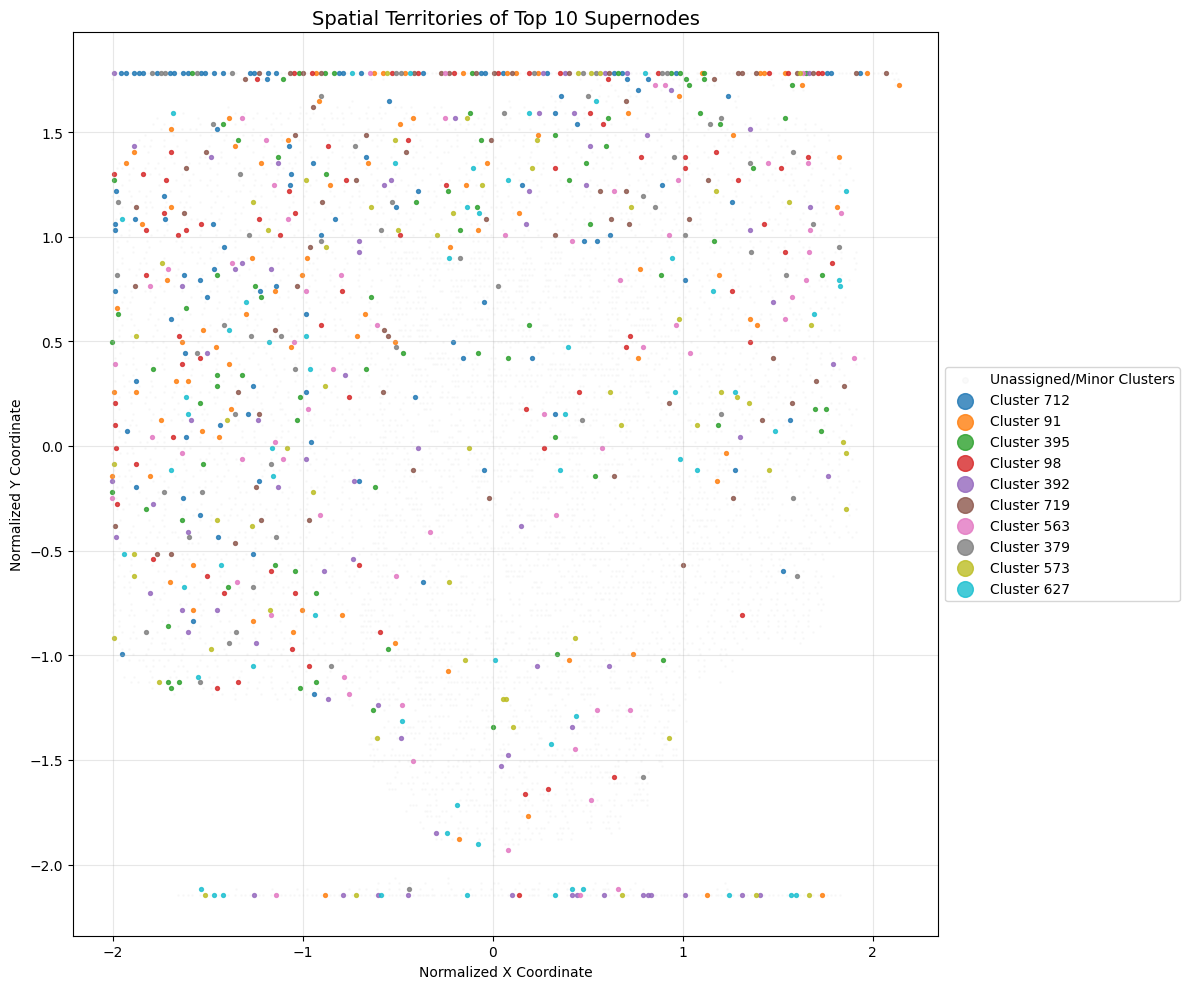

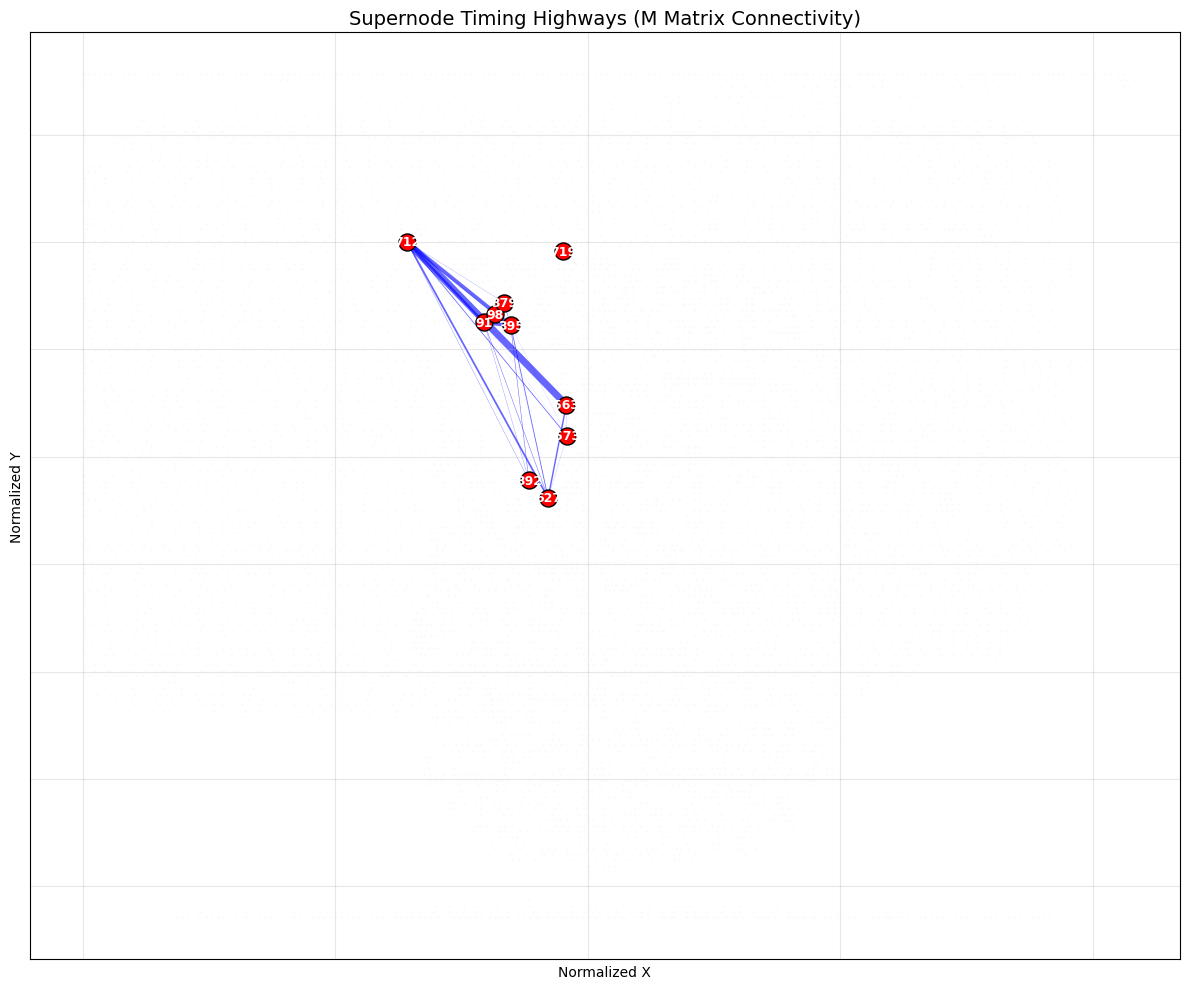

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import torch

# --- 0. RECALCULATE M (The Missing Step) ---
# We use the final 'C' from your training loop and your 'A_skip_csr'
with torch.no_grad():
    M_tensor = torch.matmul(C.t(), torch.sparse.mm(A_skip_csr, C))
    M_dense = M_tensor.cpu().numpy()

# --- 1. Extract Data from Tensors ---
# Get the "hard" cluster assignment for each node by finding the max probability
C_probs = C.detach().cpu().numpy()
hard_assignments = np.argmax(C_probs, axis=1)

# Extract X and Y coordinates (columns 0 and 1 in your X_float)
x_coords = X_float[:, 0].cpu().numpy()
y_coords = X_float[:, 1].cpu().numpy()

# --- 2. Identify the Top Clusters ---
# Count how many nodes belong to each cluster
unique_clusters, counts = np.unique(hard_assignments, return_counts=True)

# Sort to find the indices of the largest clusters
top_cluster_indices = np.argsort(-counts)[:10]
top_clusters = unique_clusters[top_cluster_indices]

print(f"Visualizing Top 10 Clusters: {top_clusters}")
print(f"Sizes of Top 10 Clusters: {counts[top_cluster_indices]}")

# =========================================================
# PLOT 1: SPATIAL TERRITORIES (The Physical Layout)
# =========================================================
plt.figure(figsize=(12, 10))

# 1. Plot all gates as faint gray background noise
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.1, label='Unassigned/Minor Clusters')

# 2. Plot the top 10 clusters in distinct colors
cmap = plt.get_cmap('tab10')
for i, cluster_id in enumerate(top_clusters):
    # Create a boolean mask for nodes in this specific cluster
    mask = (hard_assignments == cluster_id)
    plt.scatter(x_coords[mask], y_coords[mask], s=8, color=cmap(i), alpha=0.8, label=f'Cluster {cluster_id}')

plt.title("Spatial Territories of Top 10 Supernodes", fontsize=14)
plt.xlabel("Normalized X Coordinate")
plt.ylabel("Normalized Y Coordinate")
# Increase marker size in legend so it's readable
plt.legend(markerscale=4, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: SUPERNODE CONNECTIVITY (The Timing Highways)
# =========================================================
plt.figure(figsize=(12, 10))

# Plot the faint background map again for spatial context
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.05)

# Build a NetworkX graph to draw the connections
G = nx.Graph()
pos = {} # Dictionary to store the (x,y) center of each supernode

# 1. Calculate the spatial centroid of each top cluster
for cluster_id in top_clusters:
    mask = (hard_assignments == cluster_id)
    # The centroid is the average X and Y of all gates in the cluster
    centroid_x = np.mean(x_coords[mask])
    centroid_y = np.mean(y_coords[mask])
    
    pos[cluster_id] = (centroid_x, centroid_y)
    G.add_node(cluster_id)

# 2. Add edges based on the M matrix (Timing Connections)
# We calculate a threshold so we only draw the most important "highways"
sub_M = M_dense[np.ix_(top_clusters, top_clusters)]
# If all values are 0 (no timing connections between top 10), avoid threshold error
if sub_M.max() > 0:
    threshold = np.percentile(sub_M[sub_M > 0], 50) # Only keep top 50% of connections
    
    for i in top_clusters:
        for j in top_clusters:
            if i < j: # Prevent drawing duplicate undirected edges
                weight = M_dense[i, j]
                if weight > threshold:
                    G.add_edge(i, j, weight=weight)

# 3. Draw the Graph
edges = G.edges(data=True)
if len(edges) > 0:
    # Scale the line thickness based on how strong the M matrix connection is
    max_weight = max([d['weight'] for u, v, d in edges])
    edge_widths = [(d['weight'] / max_weight) * 5 for u, v, d in edges] 

    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='blue', alpha=0.6)

nx.draw_networkx_nodes(G, pos, node_color='red', node_size=150, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold')

plt.title("Supernode Timing Highways (M Matrix Connectivity)", fontsize=14)
plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
# C[1] is the row for node 1 (size [num_clusters])
max_index = torch.argmax(C[1])
print(C[2].max())
print(max_index)

max_index2 = torch.argmax(C[2])
print(max_index2)

tensor(0.7193, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(395, device='cuda:0')
tensor(146, device='cuda:0')
